In [1]:
import pandas as pd

In [5]:
import os
os.getcwd()

'C:\\Users\\truth\\Documents\\Education\\Data Analysis and Programming\\JupyterData'

In [7]:
df = pd.read_excel("laus_unemployment.xlsx")

In [9]:
df.head()

,County,Year,Period,labor force,employment,unemployment,unemployment rate
0,Apache,2010,Annual,23119,19325,3794,16.4
1,Apache,2011,Annual,22883,18661,4222,18.5
2,Apache,2012,Annual,22677,18352,4325,19.1
3,Apache,2013,Annual,21753,17710,4043,18.6
4,Apache,2014,Annual,20921,17624,3297,15.8


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   County             225 non-null    object 
 1   Year               225 non-null    int64  
 2   Period             225 non-null    object 
 3   labor force        225 non-null    int64  
 4   employment         225 non-null    int64  
 5   unemployment       225 non-null    int64  
 6   unemployment rate  225 non-null    float64
dtypes: float64(1), int64(4), object(2)
memory usage: 12.4+ KB


In [14]:
df.columns = [
    "county",
    "year",
    "period",
    "labor_force",
    "employment",
    "unemployment",
    "unemployment_rate"
]

In [16]:
df = df.drop(columns=["period"])

In [18]:
df["county"] = df["county"] + " County"

In [20]:
df["unemployment_rate"] = pd.to_numeric(df["unemployment_rate"], errors="coerce")

In [22]:
df.describe()

,year,labor_force,employment,unemployment,unemployment_rate
count,225.000000,2.250000e+02,2.250000e+02,225.000000,225.000000
mean,2017.000000,2.199441e+05,2.065905e+05,13353.537778,8.309778
std,4.330127,5.280315e+05,5.014354e+05,28969.671252,4.417648
min,2010.000000,3.330000e+03,2.836000e+03,127.000000,2.400000
25%,2013.000000,2.010400e+04,1.754900e+04,1420.000000,5.200000
50%,2017.000000,4.798300e+04,4.580400e+04,3876.000000,7.300000
75%,2021.000000,9.545700e+04,8.667000e+04,9113.000000,9.800000
max,2024.000000,2.492391e+06,2.414116e+06,180192.000000,25.700000


In [24]:
df["county"].nunique()

15

In [26]:
df.to_csv("clean_unemployment.csv", index=False)

In [28]:
df.groupby("year")["county"].count()

year
2010    15
2011    15
2012    15
2013    15
2014    15
2015    15
2016    15
2017    15
2018    15
2019    15
2020    15
2021    15
2022    15
2023    15
2024    15
Name: county, dtype: int64

In [36]:
df = pd.read_csv("US Census Bureau_ACSDT5Y2024.B19013-Data.csv", skiprows=1)

In [40]:
df = pd.read_csv("US Census Bureau_ACSDT5Y2024.B19013-Data.csv", skiprows=1)

print(df.columns.tolist())
df.head()

['Geography', 'Geographic Area Name', 'Estimate!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars)', 'Margin of Error!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars)']


,Geography,Geographic Area Name,Estimate!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars),Margin of Error!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars)
0,0400000US04,Arizona,79964,407
1,0500000US04001,"Apache County, Arizona",41438,2581
2,0500000US04003,"Cochise County, Arizona",59742,1950
3,0500000US04005,"Coconino County, Arizona",72966,2339
4,0500000US04007,"Gila County, Arizona",61986,2848


In [42]:
df = pd.read_csv("US Census Bureau_ACSDT5Y2024.B19013-Data.csv", skiprows=1)

df = df.rename(columns={
    "Geographic Area Name": "county",
    "Estimate!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars)": "median_income"
})

df = df[df["county"] != "Arizona"]

df["county"] = df["county"].str.replace(", Arizona", "", regex=False)

df = df[["county", "median_income"]]

df["year"] = 2024

df.head()

,county,median_income,year
1,Apache County,41438,2024
2,Cochise County,59742,2024
3,Coconino County,72966,2024
4,Gila County,61986,2024
5,Graham County,67325,2024


In [44]:
df.to_csv("clean_income_2024.csv", index=False)

In [48]:
df = pd.read_csv("US Census Bureau_ACSST5Y2024.S1701-Data.csv", skiprows=1)

print(df.columns.tolist())

['Geography', 'Geographic Area Name', 'Estimate!!Total!!Population for whom poverty status is determined', 'Margin of Error!!Total!!Population for whom poverty status is determined', 'Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years', 'Margin of Error!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years', 'Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!Under 5 years', 'Margin of Error!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!Under 5 years', 'Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!5 to 17 years', 'Margin of Error!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!5 to 17 years', 'Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!Related children of householder under 18 years', 'Margin of Error!!Total!!Population for whom poverty statu

In [50]:
df = pd.read_csv("US Census Bureau_ACSST5Y2024.S1701-Data.csv", skiprows=1)

df.columns = df.columns.str.strip()  # removes hidden spaces

df = df.rename(columns={
    "Geographic Area Name": "county",
    "S1701_C03_001E": "poverty_rate"
})

In [54]:
df = pd.read_csv("US Census Bureau_ACSST5Y2024.S1701-Data.csv", skiprows=1)

df.columns = df.columns.str.strip()

df = df.rename(columns={
    df.columns[1]: "county",
    df.columns[2]: "poverty_rate"
})

In [56]:
df.head()

,Geography,county,poverty_rate,Margin of Error!!Total!!Population for whom poverty status is determined,Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years,Margin of Error!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years,Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!Under 5 years,Margin of Error!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!Under 5 years,Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!5 to 17 years,Margin of Error!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years!!5 to 17 years,...,Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Mean income deficit for unrelated individuals (dollars),Margin of Error!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Mean income deficit for unrelated individuals (dollars),"Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Worked full-time, year-round in the past 12 months","Margin of Error!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Worked full-time, year-round in the past 12 months","Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Worked less than full-time, year-round in the past 12 months","Margin of Error!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Worked less than full-time, year-round in the past 12 months",Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Did not work,Margin of Error!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Did not work,Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Population in housing units for whom poverty status is determined,Margin of Error!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Population in housing units for whom poverty status is determined
0,0400000US04,Arizona,7220374,1873,1566935,1947,389012,1157,1177923,1495,...,(X),(X),3.1,0.2,32.7,0.9,41.6,0.6,12.3,0.2
1,0500000US04001,"Apache County, Arizona",63929,168,16725,263,3741,13,12984,266,...,(X),(X),4.5,2.1,37.3,9.7,70.9,3.5,30.4,2.0
2,0500000US04003,"Cochise County, Arizona",119600,244,25275,167,6217,94,19058,161,...,(X),(X),2.9,1.5,30.7,5.3,37.6,3.4,15.3,1.1
3,0500000US04005,"Coconino County, Arizona",132531,362,27481,332,6416,231,21065,244,...,(X),(X),3.6,1.6,43.9,4.0,53.5,4.2,16.4,1.2
4,0500000US04007,"Gila County, Arizona",52713,148,9817,148,2261,78,7556,113,...,(X),(X),2.8,2.1,30.5,7.8,41.2,3.9,16.8,2.2


In [60]:
# Load the updated poverty dataset
poverty_df = pd.read_csv("US Census Bureau_ACSST5Y2024.S1701-Data.csv")

# Preview the first few rows to confirm the file loaded correctly
poverty_df.head()

,GEO_ID,NAME,S1701_C01_001E,S1701_C01_001M,S1701_C01_002E,S1701_C01_002M,S1701_C01_003E,S1701_C01_003M,S1701_C01_004E,S1701_C01_004M,...,S1701_C03_058E,S1701_C03_058M,S1701_C03_059E,S1701_C03_059M,S1701_C03_060E,S1701_C03_060M,S1701_C03_061E,S1701_C03_061M,S1701_C03_062E,S1701_C03_062M
0,0400000US04,Arizona,7220374,1873,1566935,1947,389012,1157,1177923,1495,...,(X),(X),3.1,0.2,32.7,0.9,41.6,0.6,12.3,0.2
1,0500000US04001,"Apache County, Arizona",63929,168,16725,263,3741,13,12984,266,...,(X),(X),4.5,2.1,37.3,9.7,70.9,3.5,30.4,2.0
2,0500000US04003,"Cochise County, Arizona",119600,244,25275,167,6217,94,19058,161,...,(X),(X),2.9,1.5,30.7,5.3,37.6,3.4,15.3,1.1
3,0500000US04005,"Coconino County, Arizona",132531,362,27481,332,6416,231,21065,244,...,(X),(X),3.6,1.6,43.9,4.0,53.5,4.2,16.4,1.2
4,0500000US04007,"Gila County, Arizona",52713,148,9817,148,2261,78,7556,113,...,(X),(X),2.8,2.1,30.5,7.8,41.2,3.9,16.8,2.2


In [62]:
# Check the column names so we can confirm what Excel left in the file
poverty_df.columns

Index(['GEO_ID', 'NAME', 'S1701_C01_001E', 'S1701_C01_001M', 'S1701_C01_002E',
       'S1701_C01_002M', 'S1701_C01_003E', 'S1701_C01_003M', 'S1701_C01_004E',
       'S1701_C01_004M',
       ...
       'S1701_C03_058E', 'S1701_C03_058M', 'S1701_C03_059E', 'S1701_C03_059M',
       'S1701_C03_060E', 'S1701_C03_060M', 'S1701_C03_061E', 'S1701_C03_061M',
       'S1701_C03_062E', 'S1701_C03_062M'],
      dtype='object', length=374)

In [64]:
# Remove any extra spaces from column names
poverty_df.columns = poverty_df.columns.str.strip()

# Rename the first two columns to clean, merge-friendly names
# Column 0 should be county name
# Column 1 should be poverty rate
poverty_df = poverty_df.rename(columns={
    poverty_df.columns[0]: "county",
    poverty_df.columns[1]: "poverty_rate"
})

In [66]:
# Remove ", Arizona" from county names if it is still included
poverty_df["county"] = poverty_df["county"].str.replace(", Arizona", "", regex=False)

# Remove leading/trailing spaces from county names
poverty_df["county"] = poverty_df["county"].str.strip()

In [68]:
# Remove the Arizona statewide row if it still exists
# I only want county-level data
poverty_df = poverty_df[poverty_df["county"] != "Arizona"]

In [70]:
# Convert poverty rate to numeric format
# errors="coerce" turns invalid values into NaN instead of crashing
poverty_df["poverty_rate"] = pd.to_numeric(poverty_df["poverty_rate"], errors="coerce")

In [72]:
# Add year column so this dataset can merge with unemployment and income data
poverty_df["year"] = 2024

In [74]:
# Keep only the columns needed for the final capstone dataset
poverty_df = poverty_df[["county", "poverty_rate", "year"]]

In [76]:
# Validate the cleaned dataset
poverty_df.head()

,county,poverty_rate,year
0,0400000US04,NaN,2024
1,0500000US04001,NaN,2024
2,0500000US04003,NaN,2024
3,0500000US04005,NaN,2024
4,0500000US04007,NaN,2024


In [78]:
# Confirm row count and column count
# Expected result should be close to (15, 3)
poverty_df.shape

(31, 3)

In [80]:
# Confirm there are 15 unique Arizona counties
poverty_df["county"].nunique()

16

In [82]:
poverty_df.columns.tolist()

['county', 'poverty_rate', 'year']

In [84]:
poverty_df = pd.read_csv("US Census Bureau_ACSST5Y2024.S1701-Data.csv")

# Clean column names
poverty_df.columns = poverty_df.columns.str.strip()

# Rename the CORRECT columns
poverty_df = poverty_df.rename(columns={
    "NAME": "county",
    "S1701_C03_001E": "poverty_rate"
})

In [86]:
# Remove state row
poverty_df = poverty_df[poverty_df["county"] != "Arizona"]

# Clean county names
poverty_df["county"] = poverty_df["county"].str.replace(", Arizona", "", regex=False)
poverty_df["county"] = poverty_df["county"].str.strip()

# Convert to numeric
poverty_df["poverty_rate"] = pd.to_numeric(poverty_df["poverty_rate"], errors="coerce")

# Add year
poverty_df["year"] = 2024

# Keep only needed columns
poverty_df = poverty_df[["county", "poverty_rate", "year"]]

poverty_df.head()

,county,poverty_rate,year
1,Apache County,30.5,2024
2,Cochise County,15.4,2024
3,Coconino County,16.8,2024
4,Gila County,16.9,2024
5,Graham County,17.3,2024


In [88]:
poverty_df.to_csv("clean_poverty_2024.csv", index=False)

In [90]:
# Load the B15003 educational attainment dataset
education_df = pd.read_csv("US Census Bureau_ACSDT5Y2024.B15003-Data.csv")

# Preview the dataset
education_df.head()

,GEO_ID,NAME,B15003_001E,B15003_001M,B15003_002E,B15003_002M,B15003_003E,B15003_003M,B15003_004E,B15003_004M,...,B15003_021E,B15003_021M,B15003_022E,B15003_022M,B15003_023E,B15003_023M,B15003_024E,B15003_024M,B15003_025E,B15003_025M
0,0400000US04,Arizona,5088675,595,90450,2707,1423,329,1287,432,...,471723,5140,1035236,9405,476310,5873,106233,3016,78561,2501
1,0500000US04001,"Apache County, Arizona",42350,249,773,128,3,6,0,33,...,4031,399,4057,379,2471,426,149,74,338,158
2,0500000US04003,"Cochise County, Arizona",89778,172,853,218,13,21,12,18,...,9678,786,15198,1007,7612,659,1275,312,1138,272
3,0500000US04005,"Coconino County, Arizona",88196,208,803,203,9,9,23,17,...,7923,745,20755,1112,10273,819,1979,300,2572,380
4,0500000US04007,"Gila County, Arizona",40390,120,216,102,14,26,5,9,...,4015,511,4740,590,2053,378,495,192,278,125


In [92]:
# Confirm column names before cleaning
education_df.columns.tolist()

['GEO_ID',
 'NAME',
 'B15003_001E',
 'B15003_001M',
 'B15003_002E',
 'B15003_002M',
 'B15003_003E',
 'B15003_003M',
 'B15003_004E',
 'B15003_004M',
 'B15003_005E',
 'B15003_005M',
 'B15003_006E',
 'B15003_006M',
 'B15003_007E',
 'B15003_007M',
 'B15003_008E',
 'B15003_008M',
 'B15003_009E',
 'B15003_009M',
 'B15003_010E',
 'B15003_010M',
 'B15003_011E',
 'B15003_011M',
 'B15003_012E',
 'B15003_012M',
 'B15003_013E',
 'B15003_013M',
 'B15003_014E',
 'B15003_014M',
 'B15003_015E',
 'B15003_015M',
 'B15003_016E',
 'B15003_016M',
 'B15003_017E',
 'B15003_017M',
 'B15003_018E',
 'B15003_018M',
 'B15003_019E',
 'B15003_019M',
 'B15003_020E',
 'B15003_020M',
 'B15003_021E',
 'B15003_021M',
 'B15003_022E',
 'B15003_022M',
 'B15003_023E',
 'B15003_023M',
 'B15003_024E',
 'B15003_024M',
 'B15003_025E',
 'B15003_025M']

In [94]:
# Remove extra spaces from column names
education_df.columns = education_df.columns.str.strip()

# Rename only the columns I need
education_df = education_df.rename(columns={
    "NAME": "county",
    "B15003_001E": "total_age_25_plus",
    "B15003_022E": "bachelors_degree",
    "B15003_023E": "masters_degree",
    "B15003_024E": "professional_degree",
    "B15003_025E": "doctorate_degree"
})

In [96]:
# Remove the statewide Arizona row
# I only want county-level data
education_df = education_df[education_df["county"] != "Arizona"]

In [98]:
# Remove ", Arizona" from county names
education_df["county"] = education_df["county"].str.replace(", Arizona", "", regex=False)

# Remove leading/trailing spaces
education_df["county"] = education_df["county"].str.strip()

In [100]:
# Convert education columns to numeric values
education_columns = [
    "total_age_25_plus",
    "bachelors_degree",
    "masters_degree",
    "professional_degree",
    "doctorate_degree"
]

for col in education_columns:
    education_df[col] = pd.to_numeric(education_df[col], errors="coerce")

In [102]:
# Calculate bachelor's degree or higher percentage
education_df["bachelors_plus_pct"] = (
    (
        education_df["bachelors_degree"] +
        education_df["masters_degree"] +
        education_df["professional_degree"] +
        education_df["doctorate_degree"]
    )
    / education_df["total_age_25_plus"]
) * 100

In [104]:
# Add year column for merging
education_df["year"] = 2024

In [106]:
# Pair down to the columns I need
education_df = education_df[["county", "bachelors_plus_pct", "year"]]

In [108]:
# Preview cleaned dataset
education_df.head()

,county,bachelors_plus_pct,year
1,Apache County,16.564345,2024
2,Cochise County,28.094856,2024
3,Coconino County,40.340832,2024
4,Gila County,18.732359,2024
5,Graham County,14.578958,2024


In [110]:
# Confirm structure
education_df.shape

(30, 3)

In [112]:
# Confirm 15 Arizona counties
education_df["county"].nunique()

15

In [114]:
# Save the cleaned education dataset
education_df.to_csv("clean_education_2024.csv", index=False)

In [116]:
# Load the dataset
lfp_df = pd.read_csv("US Census Bureau_ACSST5Y2024.S2301-Data.csv")

# Preview raw data
lfp_df.head()

,GEO_ID,NAME,S2301_C01_001E,S2301_C01_001M,S2301_C01_002E,S2301_C01_002M,S2301_C01_003E,S2301_C01_003M,S2301_C01_004E,S2301_C01_004M,...,S2301_C04_031E,S2301_C04_031M,S2301_C04_032E,S2301_C04_032M,S2301_C04_033E,S2301_C04_033M,S2301_C04_034E,S2301_C04_034M,S2301_C04_035E,S2301_C04_035M
0,0400000US04,Arizona,5975507,2526,387899,2611,498933,872,508668,483,...,4.3,0.1,6.9,0.5,5.9,0.3,4.5,0.2,2.6,0.2
1,0500000US04001,"Apache County, Arizona",50724,258,4234,174,4140,153,3966,97,...,9.7,1.3,17.5,7.1,14.5,2.6,9.1,2.0,2.1,1.3
2,0500000US04003,"Cochise County, Arizona",102646,271,6024,300,6844,139,7301,138,...,7.3,1.1,13.9,5.4,13.7,2.9,5.0,1.6,3.0,1.3
3,0500000US04005,"Coconino County, Arizona",119681,295,13500,614,17985,577,10460,212,...,4.3,0.7,10.4,4.1,5.1,1.7,5.4,1.3,2.7,0.9
4,0500000US04007,"Gila County, Arizona",44798,162,1932,262,2476,209,2553,93,...,6.8,1.9,26.2,12.8,6.5,2.8,4.8,2.2,2.5,2.2


In [118]:
# Check column names 
lfp_df.columns.tolist()

['GEO_ID',
 'NAME',
 'S2301_C01_001E',
 'S2301_C01_001M',
 'S2301_C01_002E',
 'S2301_C01_002M',
 'S2301_C01_003E',
 'S2301_C01_003M',
 'S2301_C01_004E',
 'S2301_C01_004M',
 'S2301_C01_005E',
 'S2301_C01_005M',
 'S2301_C01_006E',
 'S2301_C01_006M',
 'S2301_C01_007E',
 'S2301_C01_007M',
 'S2301_C01_008E',
 'S2301_C01_008M',
 'S2301_C01_009E',
 'S2301_C01_009M',
 'S2301_C01_010E',
 'S2301_C01_010M',
 'S2301_C01_011E',
 'S2301_C01_011M',
 'S2301_C01_012E',
 'S2301_C01_012M',
 'S2301_C01_013E',
 'S2301_C01_013M',
 'S2301_C01_014E',
 'S2301_C01_014M',
 'S2301_C01_015E',
 'S2301_C01_015M',
 'S2301_C01_016E',
 'S2301_C01_016M',
 'S2301_C01_017E',
 'S2301_C01_017M',
 'S2301_C01_018E',
 'S2301_C01_018M',
 'S2301_C01_019E',
 'S2301_C01_019M',
 'S2301_C01_020E',
 'S2301_C01_020M',
 'S2301_C01_021E',
 'S2301_C01_021M',
 'S2301_C01_022E',
 'S2301_C01_022M',
 'S2301_C01_023E',
 'S2301_C01_023M',
 'S2301_C01_024E',
 'S2301_C01_024M',
 'S2301_C01_025E',
 'S2301_C01_025M',
 'S2301_C01_026E',
 'S2301_C01

In [120]:
# Clean column names to remove hidden spaces
lfp_df.columns = lfp_df.columns.str.strip()

# Rename ONLY the needed columns
lfp_df = lfp_df.rename(columns={
    "NAME": "county",
    "S2301_C04_001E": "labor_force_participation_rate"
})

In [122]:
# Remove statewide Arizona row 
lfp_df = lfp_df[lfp_df["county"] != "Arizona"]

In [124]:
# Clean county names to match other datasets
lfp_df["county"] = lfp_df["county"].str.replace(", Arizona", "", regex=False)
lfp_df["county"] = lfp_df["county"].str.strip()

In [126]:
# Convert labor force participation rate to numeric
lfp_df["labor_force_participation_rate"] = pd.to_numeric(
    lfp_df["labor_force_participation_rate"],
    errors="coerce"
)

In [128]:
# Add year column for merging
lfp_df["year"] = 2024

In [130]:
# Keep only necessary columns
lfp_df = lfp_df[["county", "labor_force_participation_rate", "year"]]

In [132]:
# Validate dataset
lfp_df.head()

,county,labor_force_participation_rate,year
1,Apache County,10.7,2024
2,Cochise County,7.4,2024
3,Coconino County,5.6,2024
4,Gila County,7.1,2024
5,Graham County,7.7,2024


In [134]:
# Confirm structure
lfp_df.shape

(15, 3)

In [136]:
# Save cleaned dataset
lfp_df.to_csv("clean_lfp_2024.csv", index=False)

In [138]:
# Load the DP05 demographic profile dataset
dp05_df = pd.read_csv("US Census Bureau_ACSDP5Y2024.DP05-Data.csv")

# Preview the raw data
dp05_df.head()

,GEO_ID,NAME,DP05_0001E,DP05_0001M,DP05_0002E,DP05_0002M,DP05_0003E,DP05_0003M,DP05_0004E,DP05_0004M,...,DP05_0104PE,DP05_0104PM,DP05_0105PE,DP05_0105PM,DP05_0106PE,DP05_0106PM,DP05_0107PE,DP05_0107PM,DP05_0108PE,DP05_0108PM
0,0400000US04,Arizona,7378838,*****,3683473,566,3695365,566,99.7,0.1,...,3.6,0.1,(X),(X),5324116,(X),49.5,0.1,50.5,0.1
1,0500000US04001,"Apache County, Arizona",65341,*****,32217,168,33124,168,97.3,1,...,1.9,0.5,(X),(X),47968,(X),49.2,0.2,50.8,0.2
2,0500000US04003,"Cochise County, Arizona",125566,*****,63772,128,61794,128,103.2,0.4,...,4.1,0.3,(X),(X),94527,(X),51.3,0.3,48.7,0.3
3,0500000US04005,"Coconino County, Arizona",144508,*****,71308,84,73200,84,97.4,0.2,...,3.7,0.5,(X),(X),112728,(X),49.1,0.2,50.9,0.2
4,0500000US04007,"Gila County, Arizona",53795,*****,26953,109,26842,109,100.4,0.8,...,8.9,1.2,(X),(X),43145,(X),49.8,0.3,50.2,0.3


In [140]:
# Remove hidden spaces from column names
dp05_df.columns = dp05_df.columns.str.strip()

# Rename only the columns needed 
dp05_df = dp05_df.rename(columns={
    "NAME": "county",
    "DP05_0001E": "total_population",
    "DP05_0018E": "median_age"
})

In [142]:
# Remove statewide Arizona row
# I only want county-level records
dp05_df = dp05_df[dp05_df["county"] != "Arizona"]

In [144]:
# Clean county names so they match the other datasets
dp05_df["county"] = dp05_df["county"].str.replace(", Arizona", "", regex=False)
dp05_df["county"] = dp05_df["county"].str.strip()

In [146]:
# Convert selected demographic fields to numeric values
dp05_df["total_population"] = pd.to_numeric(dp05_df["total_population"], errors="coerce")
dp05_df["median_age"] = pd.to_numeric(dp05_df["median_age"], errors="coerce")

In [148]:
# Add year column for merging with the other 2024 datasets
dp05_df["year"] = 2024

In [150]:
# Keep only the columns needed for the final merged dataset
dp05_df = dp05_df[["county", "total_population", "median_age", "year"]]

In [152]:
# Preview cleaned dataset
dp05_df.head()

,county,total_population,median_age,year
1,Apache County,65341,36.6,2024
2,Cochise County,125566,43.0,2024
3,Coconino County,144508,32.8,2024
4,Gila County,53795,51.1,2024
5,Graham County,39232,34.9,2024


In [154]:
# Confirm structure
# Expected result should be 15 rows and 4 columns
dp05_df.shape

(15, 4)

In [156]:
# Save the cleaned DP05 dataset
dp05_df.to_csv("clean_population_2024.csv", index=False)

In [158]:
# Load the PolicyMap unemployment file
# remove the extra PolicyMap metadata/header row
unemployment_pm_df = pd.read_csv(
    "Unemployment_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv",
    skiprows=1
)

# Preview the raw imported data
unemployment_pm_df.head()

,County,Apache,AZ,4001,04001,6.9,2024,2022,BLS,Arizona (State)
0,County,Cochise,AZ,4003,4003,4.2,2024,2022,BLS,Arizona (State)
1,County,Coconino,AZ,4005,4005,3.9,2024,2022,BLS,Arizona (State)
2,County,Gila,AZ,4007,4007,3.7,2024,2022,BLS,Arizona (State)
3,County,Graham,AZ,4009,4009,3.3,2024,2022,BLS,Arizona (State)
4,County,Greenlee,AZ,4011,4011,2.4,2024,2022,BLS,Arizona (State)


In [160]:
# Remove hidden spaces from column names
unemployment_pm_df.columns = unemployment_pm_df.columns.str.strip()

# Rename the columns needed for analysis and merging
unemployment_pm_df = unemployment_pm_df.rename(columns={
    "Geography Name": "county",
    "Unemployment Rate": "unemployment_rate",
    "Data Time Period": "year"
})

In [164]:
unemployment_pm_df.columns.tolist()

['County',
 'Apache',
 'AZ',
 '4001',
 '04001',
 '6.9',
 '2024',
 '2022',
 'BLS',
 'Arizona (State)']

In [168]:
# Reload file without skipping a row
unemployment_pm_df = pd.read_csv(
    "Unemployment_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv"
)

# Preview the raw file
unemployment_pm_df.head()

,GeoID_Description,GeoID_Name,SitsinState,GeoID,GeoID_Formatted,unemprate,TimeFrame,GeoVintage,Source,Location
0,County,Apache,AZ,4001,4001,6.9,2024,2022,BLS,Arizona (State)
1,County,Cochise,AZ,4003,4003,4.2,2024,2022,BLS,Arizona (State)
2,County,Coconino,AZ,4005,4005,3.9,2024,2022,BLS,Arizona (State)
3,County,Gila,AZ,4007,4007,3.7,2024,2022,BLS,Arizona (State)
4,County,Graham,AZ,4009,4009,3.3,2024,2022,BLS,Arizona (State)


In [170]:
# Drop the first row because it contains PolicyMap field descriptions, not actual data
unemployment_pm_df = unemployment_pm_df.iloc[1:].copy()

In [172]:
# Clean column names
unemployment_pm_df.columns = unemployment_pm_df.columns.str.strip()

# Rename the columns we need
unemployment_pm_df = unemployment_pm_df.rename(columns={
    "Geography Name": "county",
    "Unemployment Rate": "unemployment_rate",
    "Data Time Period": "year"
})

In [176]:
# Load the PolicyMap unemployment file
unemployment_pm_df = pd.read_csv(
    "Unemployment_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv"
)

# Clean column names in case there are hidden spaces
unemployment_pm_df.columns = unemployment_pm_df.columns.str.strip()

# Rename the actual columns from your file
unemployment_pm_df = unemployment_pm_df.rename(columns={
    "GeoID_Name": "county",
    "unemprate": "unemployment_rate",
    "TimeFrame": "year"
})

# Add "County" to match your other cleaned datasets
unemployment_pm_df["county"] = unemployment_pm_df["county"].str.strip() + " County"

# Convert fields to numeric
unemployment_pm_df["unemployment_rate"] = pd.to_numeric(
    unemployment_pm_df["unemployment_rate"],
    errors="coerce"
)

unemployment_pm_df["year"] = pd.to_numeric(
    unemployment_pm_df["year"],
    errors="coerce"
)

# Keep only needed columns
unemployment_pm_df = unemployment_pm_df[[
    "county",
    "unemployment_rate",
    "year"
]]

# Preview cleaned dataset
unemployment_pm_df.head()

,county,unemployment_rate,year
0,Apache County,6.9,2024
1,Cochise County,4.2,2024
2,Coconino County,3.9,2024
3,Gila County,3.7,2024
4,Graham County,3.3,2024


In [178]:
# Confirm shape: should be 15 rows and 3 columns
unemployment_pm_df.shape

(15, 3)

In [180]:
# Save cleaned PolicyMap unemployment file
unemployment_pm_df.to_csv("clean_unemployment_policymap_2024.csv", index=False)

In [1]:
# Import pandas (took a break from this file, so re-importing, because my connection got lost)
import pandas as pd

# Load the PolicyMap median household income file
income_pm_df = pd.read_csv(
    "Median Household Income_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv"
)

# Preview the raw data
income_pm_df.head()

,Geography Type Description,Geography Name,Sits in State,GeoID,Formatted GeoID,Median Household Income,Data Time Period,Geographic Vintage,Data Source,Selected Location
0,County,Apache,AZ,4001,4001,41438,2020-2024,2022,Census,Arizona (State)
1,County,Cochise,AZ,4003,4003,59742,2020-2024,2022,Census,Arizona (State)
2,County,Coconino,AZ,4005,4005,72966,2020-2024,2022,Census,Arizona (State)
3,County,Gila,AZ,4007,4007,61986,2020-2024,2022,Census,Arizona (State)
4,County,Graham,AZ,4009,4009,67325,2020-2024,2022,Census,Arizona (State)


In [3]:
# Remove hidden spaces from column names
income_pm_df.columns = income_pm_df.columns.str.strip()

# Rename the needed columns for merging
income_pm_df = income_pm_df.rename(columns={
    "Geography Name": "county",
    "Median Household Income": "median_income",
    "Data Time Period": "year"
})

In [5]:
# Add "County" to match your other cleaned datasets
# Example: Apache -> Apache County
income_pm_df["county"] = income_pm_df["county"].str.strip() + " County"

In [7]:
# Convert median income and year to numeric values
income_pm_df["median_income"] = pd.to_numeric(
    income_pm_df["median_income"],
    errors="coerce"
)

income_pm_df["year"] = pd.to_numeric(
    income_pm_df["year"],
    errors="coerce"
)

In [9]:
# Keep only the columns needed for the final dataset
income_pm_df = income_pm_df[[
    "county",
    "median_income",
    "year"
]]

In [11]:
# Validate the cleaned dataset
income_pm_df.head()

,county,median_income,year
0,Apache County,41438,NaN
1,Cochise County,59742,NaN
2,Coconino County,72966,NaN
3,Gila County,61986,NaN
4,Graham County,67325,NaN


In [15]:
# Assign representative year
income_pm_df["year"] = 2024

In [17]:
income_pm_df.head()

,county,median_income,year
0,Apache County,41438,2024
1,Cochise County,59742,2024
2,Coconino County,72966,2024
3,Gila County,61986,2024
4,Graham County,67325,2024


In [19]:
# Save the cleaned income dataset
income_pm_df.to_csv("clean_income_policymap_2024.csv", index=False)

In [23]:
# Load the PolicyMap poverty dataset
poverty_pm_df = pd.read_csv(
    "Poverty Rate_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv"
)

# Preview raw file
poverty_pm_df.head()

,Geography Type Description,Geography Name,Sits in State,GeoID,Formatted GeoID,Percent of People in Poverty,Data Time Period,Geographic Vintage,Data Source,Selected Location
0,County,Apache,AZ,4001,4001,30.53,2020-2024,2022,Census,Arizona (State)
1,County,Cochise,AZ,4003,4003,15.42,2020-2024,2022,Census,Arizona (State)
2,County,Coconino,AZ,4005,4005,16.77,2020-2024,2022,Census,Arizona (State)
3,County,Gila,AZ,4007,4007,16.89,2020-2024,2022,Census,Arizona (State)
4,County,Graham,AZ,4009,4009,17.26,2020-2024,2022,Census,Arizona (State)


In [25]:
# Clean column names to remove hidden spaces
poverty_pm_df.columns = poverty_pm_df.columns.str.strip()

# Rename columns based on your file structure
poverty_pm_df = poverty_pm_df.rename(columns={
    "GeoID_Name": "county",
    "povertyrate": "poverty_rate",
    "TimeFrame": "year"
})

In [29]:
# Received an error on the code, so re-loading the file
poverty_pm_df = pd.read_csv(
    "Poverty Rate_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv"
)

# Clean hidden spaces from column names
poverty_pm_df.columns = poverty_pm_df.columns.str.strip()

# Rename columns based on the actual file headers
poverty_pm_df = poverty_pm_df.rename(columns={
    "Geography Name": "county",
    "Percent of People in Poverty": "poverty_rate",
    "Data Time Period": "year"
})

# Add "County" to match other datasets
poverty_pm_df["county"] = poverty_pm_df["county"].str.strip() + " County"

# Convert poverty rate to numeric
poverty_pm_df["poverty_rate"] = pd.to_numeric(
    poverty_pm_df["poverty_rate"],
    errors="coerce"
)

# Set year to 2024 for consistency
poverty_pm_df["year"] = 2024

# Keep only needed columns
poverty_pm_df = poverty_pm_df[["county", "poverty_rate", "year"]]

# Preview cleaned dataset
poverty_pm_df.head()

,county,poverty_rate,year
0,Apache County,30.53,2024
1,Cochise County,15.42,2024
2,Coconino County,16.77,2024
3,Gila County,16.89,2024
4,Graham County,17.26,2024


In [31]:
poverty_pm_df.to_csv("clean_poverty_policymap_2024.csv", index=False)

In [33]:
# Load the PolicyMap education dataset
education_pm_df = pd.read_csv(
    "Bachelors Degree or Higher_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv"
)

# Preview raw data
education_pm_df.head()

,Geography Type Description,Geography Name,Sits in State,GeoID,Formatted GeoID,Percent Population with At Least Bachelor's Degree,Data Time Period,Geographic Vintage,Data Source,Selected Location
0,County,Apache,AZ,4001,4001,16.56,2020-2024,2022,Census,Arizona (State)
1,County,Cochise,AZ,4003,4003,28.09,2020-2024,2022,Census,Arizona (State)
2,County,Coconino,AZ,4005,4005,40.34,2020-2024,2022,Census,Arizona (State)
3,County,Gila,AZ,4007,4007,18.73,2020-2024,2022,Census,Arizona (State)
4,County,Graham,AZ,4009,4009,14.58,2020-2024,2022,Census,Arizona (State)


In [35]:
# Clean hidden spaces from column names
education_pm_df.columns = education_pm_df.columns.str.strip()

# Rename columns to match your modeling dataset
education_pm_df = education_pm_df.rename(columns={
    "Geography Name": "county",
    "Bachelor's Degree or Higher": "bachelors_plus_pct",
    "Data Time Period": "year"
})

In [37]:
# Add "County" to match your other datasets
education_pm_df["county"] = education_pm_df["county"].str.strip() + " County"

In [41]:
education_pm_df.columns.tolist()

['Geography Type Description',
 'county',
 'Sits in State',
 'GeoID',
 'Formatted GeoID',
 "Percent Population with At Least Bachelor's Degree",
 'year',
 'Geographic Vintage',
 'Data Source',
 'Selected Location']

In [43]:
education_pm_df = education_pm_df.rename(columns={
    "Geography Name": "county",
    "Percent Population with At Least Bachelor's Degree": "bachelors_plus_pct",
    "Data Time Period": "year"
})

In [45]:
education_pm_df["bachelors_plus_pct"] = pd.to_numeric(
    education_pm_df["bachelors_plus_pct"],
    errors="coerce"
)

In [47]:
# Set year to 2024 for consistency across all datasets
education_pm_df["year"] = 2024

In [49]:
# Keep only required columns
education_pm_df = education_pm_df[[
    "county",
    "bachelors_plus_pct",
    "year"
]]

In [51]:
# Validate cleaned dataset
education_pm_df.head()

,county,bachelors_plus_pct,year
0,Apache County,16.56,2024
1,Cochise County,28.09,2024
2,Coconino County,40.34,2024
3,Gila County,18.73,2024
4,Graham County,14.58,2024


In [53]:
# Save cleaned dataset
education_pm_df.to_csv("clean_education_policymap_2024.csv", index=False)

In [55]:
# Load the PolicyMap labor force file
labor_force_df = pd.read_csv(
    "Labor Force Participation_AZ_County_PolicyMap Data 2026-04-30 182045 UTC.csv"
)

# Preview the raw dataset
labor_force_df.head()

,Geography Type Description,Geography Name,Sits in State,GeoID,Formatted GeoID,Number in Labor Force,Data Time Period,Geographic Vintage,Data Source,Selected Location
0,County,Apache,AZ,4001,4001,18218,2024,2022,BLS,Arizona (State)
1,County,Cochise,AZ,4003,4003,47983,2024,2022,BLS,Arizona (State)
2,County,Coconino,AZ,4005,4005,75759,2024,2022,BLS,Arizona (State)
3,County,Gila,AZ,4007,4007,21412,2024,2022,BLS,Arizona (State)
4,County,Graham,AZ,4009,4009,16809,2024,2022,BLS,Arizona (State)


In [57]:
# Remove hidden spaces from column names
labor_force_df.columns = labor_force_df.columns.str.strip()

# Rename the actual columns from the file
labor_force_df = labor_force_df.rename(columns={
    "Geography Name": "county",
    "Number in Labor Force": "labor_force",
    "Data Time Period": "year"
})

In [59]:
# Add "County" to match other cleaned datasets
# Example: Apache -> Apache County
labor_force_df["county"] = labor_force_df["county"].str.strip() + " County"

In [61]:
# Convert labor force and year to numeric values
labor_force_df["labor_force"] = pd.to_numeric(
    labor_force_df["labor_force"],
    errors="coerce"
)

labor_force_df["year"] = pd.to_numeric(
    labor_force_df["year"],
    errors="coerce"
)

In [63]:
# Keep only the columns needed for merging
labor_force_df = labor_force_df[[
    "county",
    "labor_force",
    "year"
]]

In [65]:
# Preview cleaned dataset
labor_force_df.head()

,county,labor_force,year
0,Apache County,18218,2024
1,Cochise County,47983,2024
2,Coconino County,75759,2024
3,Gila County,21412,2024
4,Graham County,16809,2024


In [67]:
# Confirm expected structure: 15 rows, 3 columns
labor_force_df.shape

(15, 3)

In [69]:
# Save cleaned file
labor_force_df.to_csv("clean_labor_force_policymap_2024.csv", index=False)

In [71]:
# Load all cleaned datasets
unemp = pd.read_csv("clean_unemployment.csv")
income = pd.read_csv("clean_income_2024.csv")
poverty = pd.read_csv("clean_poverty_2024.csv")
education = pd.read_csv("clean_education_2024.csv")
lfp = pd.read_csv("clean_lfp_2024.csv")
population = pd.read_csv("clean_population_2024.csv")

# Merge all datasets on county + year
df = unemp.merge(income, on=["county", "year"]) \
          .merge(poverty, on=["county", "year"]) \
          .merge(education, on=["county", "year"]) \
          .merge(lfp, on=["county", "year"]) \
          .merge(population, on=["county", "year"])

df.head()

,county,year,labor_force,employment,unemployment,unemployment_rate,median_income,poverty_rate,bachelors_plus_pct,labor_force_participation_rate,total_population,median_age
0,Apache County,2024,18218,16964,1254,6.9,41438,30.5,16.564345,10.7,65341,36.6
1,Apache County,2024,18218,16964,1254,6.9,41438,30.5,16.564345,10.7,65341,36.6
2,Apache County,2024,18218,16964,1254,6.9,41438,30.5,16.564345,10.7,65341,36.6
3,Apache County,2024,18218,16964,1254,6.9,41438,30.5,16.564345,10.7,65341,36.6
4,Apache County,2024,18218,16964,1254,6.9,41438,30.5,16.564345,10.7,65341,36.6


In [73]:
y = df["unemployment_rate"]

In [75]:
X = df[[
    "median_income",
    "poverty_rate",
    "bachelors_plus_pct",
    "labor_force_participation_rate",
    "total_population",
    "median_age"
]]

In [77]:
df.describe()

,year,labor_force,employment,unemployment,unemployment_rate,median_income,poverty_rate,bachelors_plus_pct,labor_force_participation_rate,total_population,median_age
count,120.0,1.200000e+02,1.200000e+02,120.000000,120.00000,120.000000,120.000000,120.000000,120.000000,1.200000e+02,120.000000
mean,2024.0,2.497441e+05,2.407379e+05,9006.266667,4.82000,64265.066667,16.506667,23.538475,7.086667,4.919225e+05,42.326667
std,0.0,6.139423e+05,5.948682e+05,19199.743228,2.31508,11786.430503,5.403947,8.572844,2.519935,1.121814e+06,8.203092
min,2024.0,5.267000e+03,5.140000e+03,127.000000,2.40000,41438.000000,8.200000,13.458389,2.300000,9.409000e+03,32.800000
25%,2024.0,1.821800e+04,1.696400e+04,786.000000,3.50000,55217.000000,12.000000,16.564345,5.500000,4.892600e+04,36.300000
50%,2024.0,4.798300e+04,4.594500e+04,2079.000000,3.90000,62876.000000,16.100000,20.866018,7.100000,1.255660e+05,39.500000
75%,2024.0,1.067060e+05,1.030130e+05,8235.000000,5.70000,71164.000000,17.500000,30.254079,8.800000,2.454800e+05,51.100000
max,2024.0,2.492391e+06,2.414116e+06,78275.000000,12.20000,89300.000000,30.500000,40.340832,12.200000,4.559748e+06,60.200000


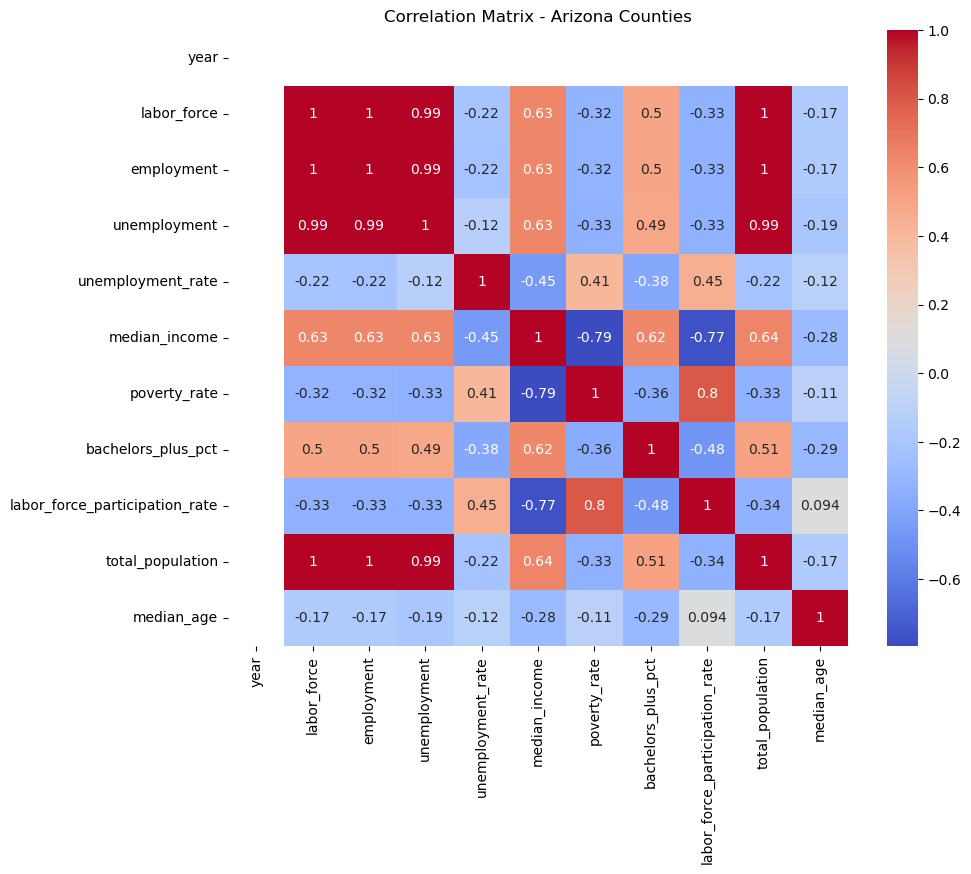

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Arizona Counties")
plt.show()

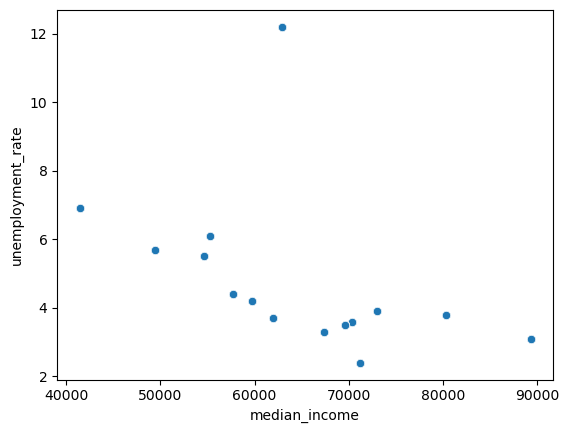

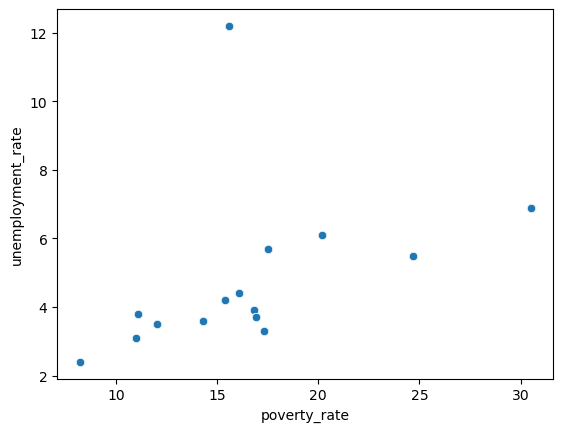

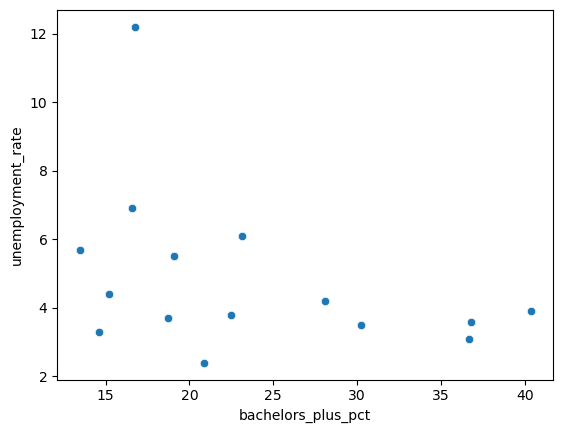

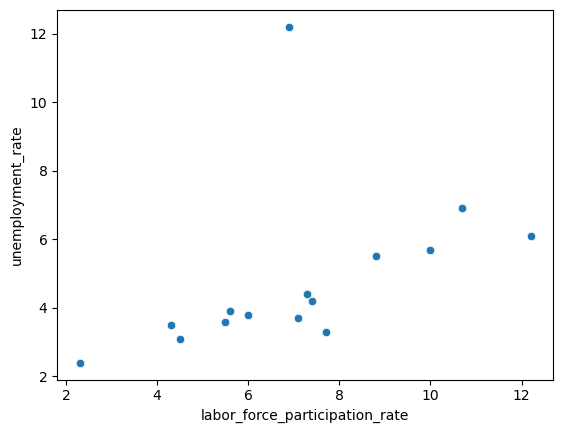

In [81]:
#

sns.scatterplot(x="median_income", y="unemployment_rate", data=df)
plt.show()

sns.scatterplot(x="poverty_rate", y="unemployment_rate", data=df)
plt.show()

sns.scatterplot(x="bachelors_plus_pct", y="unemployment_rate", data=df)
plt.show()

sns.scatterplot(x="labor_force_participation_rate", y="unemployment_rate", data=df)
plt.show()

In [85]:
# Import Linear Regression model from sklearn
from sklearn.linear_model import LinearRegression

# Initialize the regression model
model = LinearRegression()

# Fit the model using your independent variables (X) and dependent variable (y)
# This step "trains" the model to learn relationships between variables
model.fit(X, y)

# Generate predicted unemployment values based on the trained model
# These predictions will be used for performance evaluation
y_pred = model.predict(X)

In [87]:
# Create a table of model coefficients
# Each coefficient shows the relationship between an independent variable and unemployment

coefficients = pd.DataFrame({
    "Variable": X.columns,          # Names of independent variables
    "Coefficient": model.coef_      # Strength and direction of impact
})

# Display coefficients table
coefficients

,Variable,Coefficient
0,median_income,-1.329562e-04
1,poverty_rate,-1.519854e-01
2,bachelors_plus_pct,-5.347347e-02
3,labor_force_participation_rate,2.064840e-01
4,total_population,4.254201e-07
5,median_age,-1.100793e-01


In [ ]:
#positive coefficient - increases unemployment
#negative - decreases unemployment
#larger the coefficient, the more significant

In [89]:
# Import evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# R-squared measures how much of the variation in unemployment is explained by your model
print("R²:", r2_score(y, y_pred))

# MAE (Mean Absolute Error) shows the average prediction error
print("MAE:", mean_absolute_error(y, y_pred))

# RMSE (Root Mean Squared Error) penalizes larger errors more heavily
print("RMSE:", mean_squared_error(y, y_pred, squared=False))

R²: 0.33979793043058537
MAE: 1.1000487597737778
RMSE: 1.8732138122195592


C:\Users\truth\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [91]:
# Display coefficient table again for hypothesis evaluation
coefficients

,Variable,Coefficient
0,median_income,-1.329562e-04
1,poverty_rate,-1.519854e-01
2,bachelors_plus_pct,-5.347347e-02
3,labor_force_participation_rate,2.064840e-01
4,total_population,4.254201e-07
5,median_age,-1.100793e-01


In [93]:
coefficients[coefficients["Variable"] == "median_income"]

,Variable,Coefficient
0,median_income,-0.000133


In [95]:
# Compare actual vs predicted unemployment values
comparison_df = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred
})

comparison_df

,Actual,Predicted
0,6.9,7.296155
1,6.9,7.296155
2,6.9,7.296155
3,6.9,7.296155
4,6.9,7.296155
...,...,...
115,12.2,6.031637
116,12.2,6.031637
117,12.2,6.031637
118,12.2,6.031637


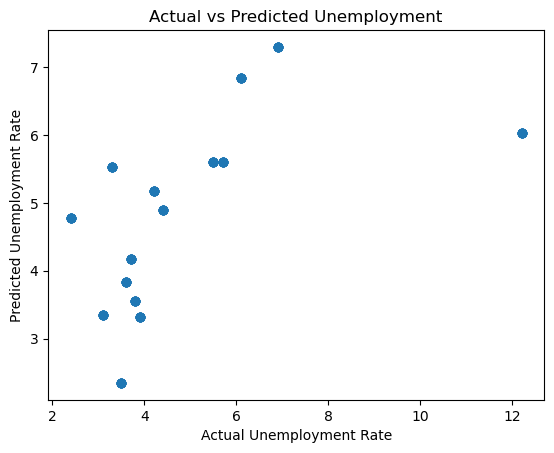

In [97]:
# Plot actual vs predicted values
plt.scatter(y, y_pred)
plt.xlabel("Actual Unemployment Rate")
plt.ylabel("Predicted Unemployment Rate")
plt.title("Actual vs Predicted Unemployment")
plt.show()

In [99]:
# Save the final merged capstone dataset as a CSV file
df.to_csv("final_capstone_dataset.csv", index=False)